<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 3 - Signal Detection Theory and Bayesian Inference</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Objectives
The objective of this TP is twofold:

1- Get familiar with model comparison/falsification with the Stimulus Detection Task
- Implement the High-threshold theory (HTT) model
- Implement the Signal Detection Theory (SDT) model
- Use the Receiver Operating Characteristic (ROC) curve to display the models

2- Understand the basic principles behind bayesian inference
- Concepts of prior, likelihood, and posterior
- Generative model
- Bayes' rule
- Bayesian inference

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
import scipy


%reload_ext autoreload
%autoreload 2

# 1- Signal Detection Theory

## Task Description
We will work on a **stimulus detection task**. In such a task, participants are asked to detect the presence of a signal in a series of trials. The signal is embedded in noise, and the participant must decide whether they think the signal is present or not.
- If the signal is present:
    - if the participant detects a signal ("Go"): **Hit** ✅
    - if the participant doesn't detect it ("No-go"): **Miss** ❌
- If the signal is NOT present:
    - if the participant detects a signal ("Go"): **False Alarm** ❌
    - if the participant doesn't detect it ("No-go"): **Correct Rejection** ✅

<img src="images/stimulus_detection_task.png" style="height: 200px; margin-left: 10px;" />

## Data loading
Here we load the data from `data.csv`.
In the dataset, each row corresponds to a trial. Data is collected for many participants, and each participant completes 2 blocks of trials. Each block has a different probability of the stimulus being present. The stimuli and responses are coded as follows:
- 1 codes for the presence of signal in the 'stim' column, and for a 'Go' response in the 'resp' column
- 0 codes for only noise in the 'stim' column, and for a 'No-go' response in the 'resp' column.

In [38]:
data = ...

In [39]:
# Solution
data = pd.read_csv('data.csv')
data

,participant,block,stim,resp
0,1,1,1,1
1,1,1,0,0
2,1,1,1,1
3,1,1,0,0
4,1,1,1,0
...,...,...,...,...
5995,2,3,0,0
5996,2,3,0,0
5997,2,3,1,1
5998,2,3,0,0


## Data visualization
To analyze the data, we will build a contingency matrix like the one illustrated in the figure below to display the hits (H), misses (M), false alarms (FA) and correct rejections (CR).
Use the data of **participant 1**, **block 1**.

<img src="images/contingency_table.png" style="height: 200px; margin-left: 10px;" />

### Contingency statistics
📝 Complete the `contingency_statistics` function, which takes in a DataFrame that contains a 'stim' and a 'resp' column **of the same participant and same block**, and returns the hit, false-alarm, miss and correct-rejection rates. A 3-step structure is proposed to write this function:
1. Extract the stimuli and responses from the dataframe
2. Count the number of hits, false alarms, misses and correct rejections in the block
3. Compute the **rates**. For this, you have to normalize the scores so that the sum of each column of the contingency table is equal to 1.

In [40]:
def contingency_statistics(data_block: pd.DataFrame):
    # Step 1
    stimuli = ...
    responses = ...

    # Step 2
    hits = ...
    fa = ...
    miss = ...
    cr = ...

    # Step 3
    hit_rate = ...
    fa_rate = ...
    miss_rate = ...
    cr_rate = ...

    return hit_rate, fa_rate, miss_rate, cr_rate

In [41]:
# Solution
def contingency_statistics(data_block: pd.DataFrame):
    # Step 1
    stimuli = data_block['stim']
    resp = data_block['resp']

    # Step 2
    correct = stimuli == resp
    hits = ((stimuli == 1) & correct).sum()
    fa = ((stimuli == 0) & ~correct).sum()
    miss = ((stimuli == 1) & ~correct).sum()
    cr = ((stimuli == 0) & correct).sum()

    # Step 3
    hit_rate = hits / (stimuli == 1).sum()
    fa_rate = fa / (stimuli == 0).sum()
    miss_rate = miss / (stimuli == 1).sum()
    cr_rate = cr / (stimuli == 0).sum()

    return hit_rate, fa_rate, miss_rate, cr_rate

Test your function. You should obtain hr=0.84, far=0.32, mr=0.16, cr=0.67.

In [42]:
# Solution
hit_rate, fa_rate, miss_rate, cr_rate = contingency_statistics(data.query('participant == 1 and block == 1'))
hit_rate, fa_rate, miss_rate, cr_rate

(np.float64(0.8446808510638298),
 np.float64(0.3264150943396226),
 np.float64(0.15531914893617021),
 np.float64(0.6735849056603773))

### Contingency matrix
Hit, miss, false alarm and correction rejection rates are usually visualized in a matrix form.
Fill the `plot_contingency_matrix` function to visualize your rates in a contingency matrix like the one shown in the figure above.
Hints:
- You can use the library Seaborn to make a *heatmap*.
- Show the rates as numbers in the cells of the matrix.
- Add a color scale to the side of the matrix.
- Make sure the x and y axes are labeled

In [7]:
def plot_contingency_matrix(hit_rate, fa_rate, miss_rate, cr_rate):
    # Your code here
    ...

plot_contingency_matrix(..., ..., ..., ...)

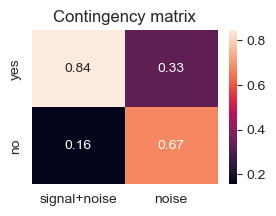

In [43]:
# Solution
def plot_contingency_matrix(hit_rate, fa_rate, miss_rate, cr_rate):
    plt.figure(figsize=(3, 2))
    sns.heatmap([[hit_rate, fa_rate],
                 [miss_rate, cr_rate]], annot=True,
                xticklabels=['signal+noise', 'noise'], yticklabels=['yes', 'no'])
    plt.title("Contingency matrix")
    plt.plot()

plot_contingency_matrix(hit_rate, fa_rate, miss_rate, cr_rate)

### Plot false alarm rate vs hit rate

📝 In a scatter plot, show the false alarm rate and the hit rate of the block on a scatter plot:
- Place the false alarm rate (FAR) on the x axis, and the hit rate (HR) on the y axis.
- Set the x and y axis limits to (0, 1)

In [44]:
def plot_hr_far(hit_rate, fa_rate):
    # Your code here
    ...

plot_hr_far(hit_rate, fa_rate)

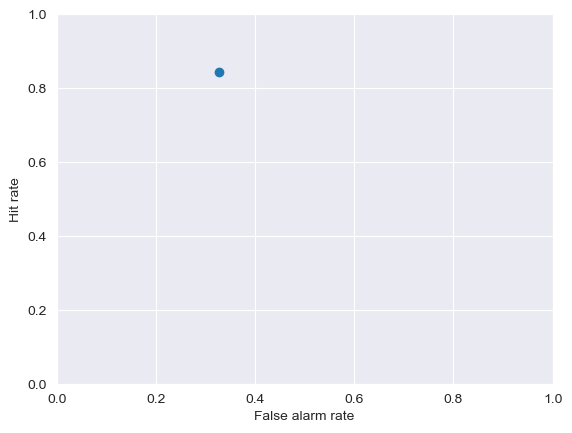

In [45]:
# Solution
def plot_hr_far(hit_rates, false_alarm_rates):
    plt.scatter(false_alarm_rates, hit_rates)
    plt.xlabel('False alarm rate')
    plt.ylabel('Hit rate')
    plt.xlim(0, 1)
    plt.ylim(0, 1)

plot_hr_far(hit_rate, fa_rate)

## Theory #1: High-threshold theory
Now it is time to model the participant's behavior.
Before using the signal detection theory, we will first start with the theory that was popular just before: **high-threshold theory**. This theory characterizes each participant by considering that he/she has a distinct **detection sensitivity**. This means that we assume that a signal $s$ will trigger an (unobserved) sensory response $r(s)$. Then, if the response is higher than the detection sensitivity $p$ ($r(s) > p$), the participant will report that they detected a stimulus ("Go"). HTT gives the following formula to estimate $p$ as a function of the hit rate (HR) and the false alarm rate (FAR):
- **Detection sensitivity**: $p = \frac{\text{HR} - \text{FAR}}{1-\text{FAR}}$

And what if the stimulus response is lower than the sensitivity threshold $p$? Then we assume that the participant guesses and reports the presence of a stimulus at a rate given by the **detection criterion**, which is equivalent to the false alarm rate (FAR):
- **Detection criterion**: $g = \text{FAR}$

### Compute detection sensitivity and criterion (HTT)
📝 Fill the `compute_htt` function, which computes $p$ and $g$ based on the hit rate and false alarm rate of a participant.

In [46]:
def compute_htt(hit_rate, fa_rate):
    p = ...
    g = ...
    return p, g

p, g = compute_htt(..., ...)

In [47]:
# Solution
def compute_htt(hit_rate, fa_rate):
    p = (hit_rate - fa_rate) / (1 - fa_rate)
    g = fa_rate
    return p, g

p, g = compute_htt(hit_rate, fa_rate)

### ROC Curve (HTT)
The purpose of the ROC curve is to visualize the performance of a binary classifier. It is a plot of the hit rate (HR) against the false alarm rate (FAR) for the different possible decision thresholds of the classifier. The ROC curve is a useful tool to compare the performance of different models.

📝 With algebraic manipulations on the HTT equations, find the linear equation that expresses the Hit rate as a function of the False Alarm rate and the detection sensitivity $p$.

$$
\begin{align}
\text{HR}   &= f_p(\text{FAR}) \\
            &= ...
\end{align}
$$

📝Fill the `plot_htt_model` function to display the ROC curve on top of the hr_far scatter plot that you made previously.
- Call the `plot_hr_far` function to display the scatter plot
- Create a vector of false alarm rates that goes from 0 to 1 (you can use `np.linspace`)
- Calculate the associated hit rates using the equation you found
- Plot the ROC curve on top of the scatter plot

In [48]:
def plot_htt_model(hit_rate, fa_rate, p):
    # Your code here
    ...

plot_htt_model(..., ..., ...)

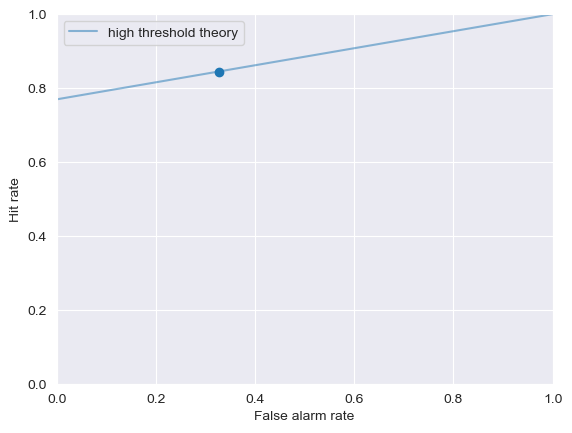

In [49]:
def plot_htt_model(hit_rate, fa_rate, p):
    plot_hr_far(hit_rate, fa_rate)
    far = np.linspace(0, 1, 100)
    hr = (1 - p) * far + p
    plt.plot(far, hr, alpha=0.5, label='high threshold theory')
    plt.legend()

plot_htt_model(hit_rate, fa_rate, p)

## Theory #2: Signal Detection Theory
Signal Detection Theory then replaced High-Threshold Theory as a reference model for stimulus detection. This theory also uses a **detection sensitivity** and a detection criterion.
- **Detection sensitivity**: $d' = z(\text{HR}) - z(\text{FAR})$ 
- **Detection criterion**: $c = - \frac{z(\text{HR}) + z(\text{FAR})}{2}$  
  where $z$ is the z-score function (see `scipy.stats.norm.ppf`)


### Compute detection sensitivity and criterion (SDT)
📝 Fill the `compute_sdt` function, which computes $d'$ and $c$ based on the hit rate and false alarm rate of a participant.

In [50]:
def compute_sdt(hit_rate, fa_rate):
    d_prime = ...
    c = ...
    return d_prime, c

d_prime, c = compute_sdt(..., ...)

In [51]:
# Solution
from scipy.stats import norm

def compute_sdt(hit_rate, fa_rate):
    d_prime = norm.ppf(hit_rate) - norm.ppf(fa_rate)
    c = - (norm.ppf(hit_rate) + norm.ppf(fa_rate)) / 2
    return d_prime, c

d_prime, c = compute_sdt(hit_rate, fa_rate)

### ROC Curve (SDT)

📝 With algebraic manipulations on the SDT equations, find the equation that expresses the Hit rate as a function of the False Alarm rate and the detection sensitivity $d'$.

$$
\begin{align}
\text{HR}   &=  f_{d'}(\text{FAR})  \\
            &=  ...
\end{align}
$$

📝 Fill the `plot_sdt_model` function to display the ROC curve on top of the hr_far scatter plot that you made previously.
Use the equation you juste derived to plot the ROC curve.

In [52]:
def plot_sdt_model(hit_rate, fa_rate, d_prime):
    # Your code here
    ...

plot_sdt_model(..., ..., ...)

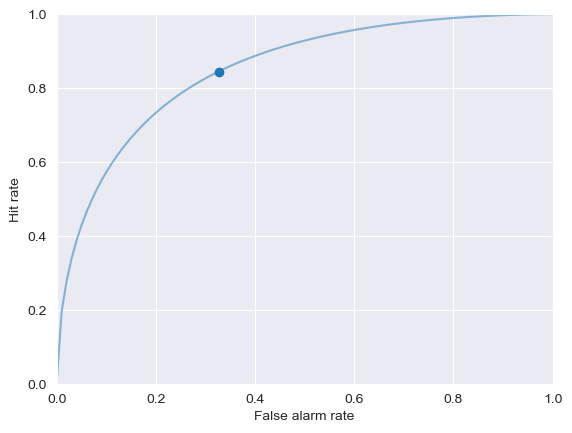

In [53]:
def plot_sdt_model(hit_rate, fa_rate, d_prime):
    plot_hr_far(hit_rate, fa_rate)
    far = np.linspace(0, 1, 100)
    hr = norm.cdf(d_prime + norm.ppf(far))
    plt.plot(far, hr, alpha=0.5, label='signal detection theory')

plot_sdt_model(hit_rate, fa_rate, d_prime)

## Model comparison
📝 Plot both ROC Curves (HT and SDT) on the same graph to compare them. Don't forget to add a legend to differentiate them.
_Hint:_ If you don't call `plt.show()` at the end of your plotting functions, you should be able to call them sequentially to display both plots on the same graph.

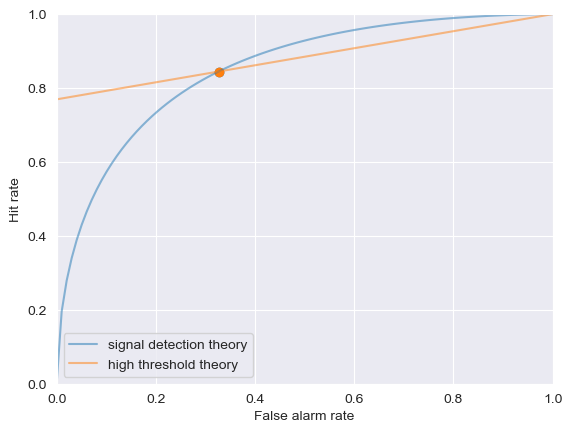

In [54]:
# Solution
plot_sdt_model(hit_rate, fa_rate, d_prime)
plot_htt_model(hit_rate, fa_rate, p)
plt.legend()
plt.show()

💭You have one data point, which corresponds to one block of data on the same task difficulty. If you have implemented the models correctly, both curves should be able to fit that point correctly. However, notice how they predict different evolutions of the hit rate of a participant if he/she is willing to allow a different.
What data would you need in order to falsify one of the models?

**Write an answer to this question before moving to the next section.**

Your answer here

## Model falsification
The dataset contains data from 3 different blocks. If we keep looking at participant 1, we can compute the hit rate and and the false alarm rates for the other two blocks. The change that is made for each block is the punishment we give them for false alarms. Therefore, they keep the same sensitivity, but they are more or less reluctant to risk saying "Go" when there is just noise.

📝Create a new plot that allows you to compare the two models on the data from participant 1, and block 1-2-3. Your plot should contain:
- A scatter plot of the hit rate and false alarm rate for each block
- The ROC curve for the HTT model fitted on the data for **block 1 only** (same as you did before)
- The ROC curve for the SDT model fitted on the data for **block 1 only** (same as you did before)

_Hint:_ There are many ways you can achieve this. The cleanest way would be to write a custom function that does all this, but you can also reuse the code from last question and just add the data points from blocks 2 and 3.

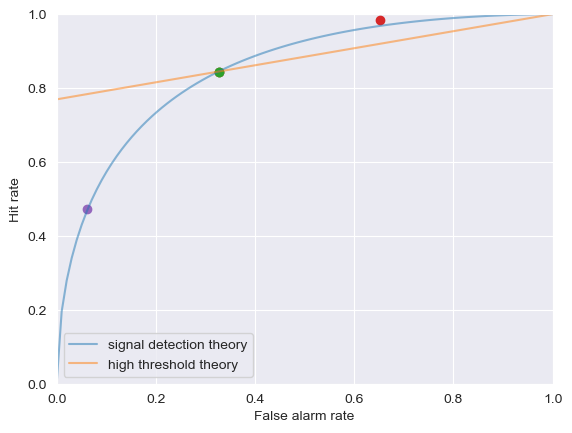

In [55]:
plot_sdt_model(hit_rate, fa_rate, d_prime)
plot_htt_model(hit_rate, fa_rate, p)
for block, data_block in data[data['participant'] == 1].groupby('block'):
    hit_rate, fa_rate, _, _ = contingency_statistics(data_block)
    plot_hr_far(hit_rate, fa_rate)
plt.legend()
plt.show()

💭Can you falsify one of the models with this new data?

# 2- Bayesian Inference
In this second part of the TD, we will introduce the basic principles behind Bayesian inference, namely **Bayes' Rule**.
Bayes' rule is crucial for understanding perception, and we will use it throughout the course. In this section, we will see how to use it on a very simple example, from the book [*Bayesian Models of Perception and Action*](https://www.cns.nyu.edu/malab/bayesianbook.html)$^{(1)}$. Imagine that you are walking in the school's corridor and you see a shiny floor. Will you assume that it is wet or that it is just a mere reflection? Will you instinctively start walking cautiously when you see it?

To analyze the situation, we need to break it down into its possiblities:
- We consider that the floor can have two possible states: **wet** or **dry**
- We can make two possible observations when looking at the floor: it can be **shiny** or **not shiny**.

The figure below shows a shiny floor, and how this observation can transform our prior belief about the usual wetness of that floor, into an updated belief, considering what we observe. We will break down the notions of **prior**, **posterior** and **likelihood** in this exercise.

<img src="images/bayesian_example.png" style="height: 200px; margin-left: 10px;" />

## Step 1: Generative model

The first step of Bayesian modeling is the **generative model**, which represents the statistical structure of the world and the observations. As mentioned above, we consider in our example two possible world states, each of which can generate two possible observations. In the generative model, we need to specify the probability distributions of all variables of the problem.

From our previous experience as an observer, we assume the following:
- **Base rate:** In general, the floor has a 10% probability of being wet.
- **Conditional probability:** If the floor is wet, it has a 80% probabililty of being shiny.
- **Conditional probability:** If the floor is dry, it has a 40% probability of being shiny.

The figure below illustrates the generative model. The conditional probabilities are left for you to deduce from the above statement.

<img src="images/generative_model.png" style="height: 200px; margin-left: 10px;" />

📝 Define the `priors` of each state of the world (regardless of the observation):
- $p(\text{wet})$
- $p(\text{dry})$

In [1]:
priors = {
    'wet': ...,
    'dry': ...
}

In [7]:
# Solution
priors = {
    'wet': 0.1,
    'dry': 0.9
}

📝 Define the `likelihoods` of each observation, under each hypothesis. They correspond to the conditional probabilities. The values that you need to enter in this dictionary are, in order:
- $p(\text{shiny}|\text{wet})$
- $p(\text{not shiny}|\text{wet})$
- $p(\text{shiny}|\text{dry})$
- $p(\text{not shiny}|\text{dry})$

In [8]:
likelihoods = {
    'wet': {
        'shiny': ...,
        'not_shiny': ...
    },
    'dry': {
        'shiny': ...,
        'not_shiny': ...
    }
}

In [9]:
# Solution
likelihoods = {
    'wet': {
        'shiny': 0.8,
        'not_shiny': 0.2
    },
    'dry': {
        'shiny': 0.4,
        'not_shiny': 0.6
    }
}

## Step 2: Inference

Now that we have defined the alterative hypotheses on the possible states of the floor (_wet_ or _dry_), your priors for each of them, and the likelihoods of each possible observation under each hypothesis, let's perform **inference**.  

Inference is done when we make an **observation**.

**_Obsevation:_** Suppose that the observer **sees the floor as shiny**. What can they infer on its actual **state** (i.e. the probability of it being wet)?

<img src="images/inference.png" style="height: 150px; margin-left: 10px;" />

We use **Bayes' rule** as a formula to update the prior belief and take into consideration the observation:

$$
\underbrace{P(H|\text{obs})}_\text{posterior} = \frac{\overbrace{p(\text{obs|H})}^\text{likelihood}\overbrace{p(H)}^\text{prior}}{p(\text{obs})}
$$

Let's break this down with our example. Let's say that we want to evaluate the probability that the floor is _wet_, given that we see it _shiny_.  
- In other words, we are looking for $p(\text{wet}|\text{shiny})$, the **posterior** that is informed by the obsevation.
- This probability is proportional to the **likelihood** of any wet floor to be perceived as shiny, $P(\text{shiny}|\text{wet})$, modulated by the how often we encounter wet floors in general $p(\text{wet})$ (our **prior**).
- This numerator is equivalent to the probability of seeing a _wet_ AND _shiny_ floor (also known as _joint probability_)
- To get the posterior, we need to divide the joint probability by the probability of seeing a shiny floor in general $p(\text{shiny})$ (**normalizing constant**)

The denominator $p(\text{shiny})$ represents the probability of seeing a shiny floor in all possible world states. This piece of information isn't given to you, but I let you think about how you can calculate it. Don't hesitate to discuss it with your neighbor if you haven't done this before.

📝 Complete the `bayesian_inference` function below. It takes as an input:
- An `observation` (as a string: 'shiny' or 'not_shiny')
- the `priors` (the dictionary you defined above)
- the `likelihoods` (the dictionary you defined above)

It then computes and returns the `posteriors` dictionary. The latter has exactly the same format as the priors, except that the probability values will have changed. 

In [10]:
def bayesian_inference(observation: str, priors: dict, likelihoods: dict) -> dict:
    posteriors = {}   # Create the output dictionary
    hypotheses = priors.keys()  # The keys of the priors dictionary are ['wet', 'dry']

    # Compute a posterior probability for each hypothesis
    for hypothesis in hypotheses:
        # Your code here
        ...

        posteriors[hypotesis] = ...
        
    return posteriors

In [11]:
# Solution
def bayesian_inference(observation: str, priors: dict, likelihoods: dict) -> dict:
    posteriors = {}
    hypotheses = priors.keys()
    
    for hypothesis in hypotheses:
        protoposterior = likelihoods[hypothesis][observation] * priors[hypothesis]
        normalization = sum(likelihoods[hyp][observation] * priors[hyp] 
                            for hyp in hypotheses)
        posteriors[hypothesis] = protoposterior / normalization
    return posteriors

Imagine that you **observe** a _shiny_ floor, just as in the example we gave. 

📝 Call your `bayesian_inference` function with the hypothesis that you want to evaluate. You have unit tests to check that your implementation is correct.

In [16]:
observation = ...

posteriors = bayesian_inference(..., ..., ...)
print(posteriors)

# Unit tests
assert isinstance(posteriors, dict), "Your posterior should be a dictionary"
assert set(posteriors.keys()) == {'wet', 'dry'}, "Your posteriors dictionary should have the same format as the priors."
assert math.isclose(posteriors['wet'], 0.182, abs_tol=0.001), "Incorrect posterior value for the 'wet' hypothesis"
assert math.isclose(posteriors['dry'], 0.818, abs_tol=0.001), "Incorrect posterior value for the 'dry' hypothesis"
print("OK 👌")

AttributeError: 'ellipsis' object has no attribute 'keys'

In [17]:
# Solution
observation = 'shiny'

posteriors = bayesian_inference(observation, priors, likelihoods)
print(posteriors)

# Unit tests
assert isinstance(posteriors, dict), "Your posterior should be a dictionary"
assert set(posteriors.keys()) == {'wet', 'dry'}, "Your posteriors dictionary should have the same format as the priors."
assert math.isclose(posteriors['wet'], 0.182, abs_tol=0.001), "Incorrect posterior value for the 'wet' hypothesis"
assert math.isclose(posteriors['dry'], 0.818, abs_tol=0.001), "Incorrect posterior value for the 'dry' hypothesis"
print("OK 👌")

{'wet': 0.18181818181818182, 'dry': 0.8181818181818181}
OK 👌


📝 Call your `bayesian_inference` function with the other observation and see how the posterior changes

In [19]:
# Solution
bayesian_inference('not_shiny', priors, likelihoods)

{'wet': 0.03571428571428572, 'dry': 0.9642857142857143}

📝 Change the prior and see how it impacts the inference.

In [ ]:
new_prior = {
    ...
}
observation = ...

bayesian_inference(..., ..., ...)

In [21]:
# Solution
new_prior = {
    'wet': 0.5,
    'dry': 0.5
}
observation = 'shiny'

bayesian_inference(observation, new_prior, likelihoods)

{'wet': 0.6666666666666666, 'dry': 0.3333333333333333}

### References: 
Ma, W. J., Kording, K. P., & Goldreich, D. (2023). Bayesian Models of Perception and Action: An Introduction. MIT press.  
Available https://www.cns.nyu.edu/malab/bayesianbook.html
